
# 🌍 Kalkınmanın Bedeli: Ekonomik Büyüme, Sağlık ve Çevre Arasındaki Dengesizlik

Bu notebook, WDI (World Development Indicators) verisini kullanarak ekonomik kalkınma, sağlık iyileşmeleri ve çevresel etkiler arasındaki dengeyi inceler.

**Ana fikir:**  
> "Gelir arttıkça sağlık kazanımları artıyor, fakat çevre yükü de beraberinde büyüyor."

**Veri Kaynağı:** World Bank WDI (2000–2023)

**Temalar:**  
- Ekonomik büyüme  
- Sağlık sistemleri  
- Çevre ve sürdürülebilirlik


In [1]:

# ==========================
# 0) Kurulum ve Dosya Yolları
# ==========================
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd()
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

WDI_CSV = DATA_DIR / "WDICSV.csv"
WDI_COUNTRY = DATA_DIR / "WDICountry.csv"

print("Dosyalar mevcut mu?")
for p in [WDI_CSV, WDI_COUNTRY]:
    print(p.name, "->", p.exists())
print("Çıktı klasörü:", FIG_DIR)


Dosyalar mevcut mu?
WDICSV.csv -> True
WDICountry.csv -> True
Çıktı klasörü: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures


In [2]:

# 1) Veriyi Yükleme ve Uzun Formata Çevirme
wide = pd.read_csv(WDI_CSV)
print("Ham veri boyutu:", wide.shape)
year_cols = [c for c in wide.columns if c.isdigit()]

long = wide.melt(id_vars=['Country Name','Country Code','Indicator Name','Indicator Code'],
                 value_vars=year_cols,
                 var_name='Year',
                 value_name='Value')
long['Year'] = pd.to_numeric(long['Year'], errors='coerce')
long = long.dropna(subset=['Year']).reset_index(drop=True)

country_meta = pd.read_csv(WDI_COUNTRY)[['Country Code','Region','Income Group']]
long = long.merge(country_meta, on='Country Code', how='left')


Ham veri boyutu: (403256, 69)


In [3]:

# 2) Odak Göstergeleri Seçme
indicator_map = {
    "NY.GDP.PCAP.CD": "GDP per capita (current US$)",
    "SP.DYN.LE00.IN": "Life expectancy at birth (years)",
    "EN.ATM.CO2E.PC": "CO2 emissions per capita (metric tons)",
    "EG.FEC.RNEW.ZS": "Renewable energy consumption (% of total final energy use)"
}

focus = long[long['Indicator Code'].isin(indicator_map.keys())].copy()
focus['Indicator'] = focus['Indicator Code'].map(indicator_map)
focus = focus[focus['Year']>=2000]


In [4]:

# 3) K-Means ile Gelir Grupları
gdp = focus[focus['Indicator Code']=="NY.GDP.PCAP.CD"].dropna(subset=['Value'])
gdp_avg = gdp.groupby(['Country Code','Country Name'])['Value'].mean().reset_index(name='gdp_avg')

X = StandardScaler().fit_transform(gdp_avg[['gdp_avg']])
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
gdp_avg['kmeans_group'] = kmeans.fit_predict(X)

order = gdp_avg.groupby('kmeans_group')['gdp_avg'].mean().sort_values().index.tolist()
mapping = {old:new for new, old in enumerate(order)}
gdp_avg['kmeans_group'] = gdp_avg['kmeans_group'].map(mapping)

labels = {0:"Low",1:"Lower-Middle",2:"Upper-Middle",3:"High"}
gdp_avg['Group'] = gdp_avg['kmeans_group'].map(labels)

focus = focus.merge(gdp_avg[['Country Code','Group']], on='Country Code', how='left')


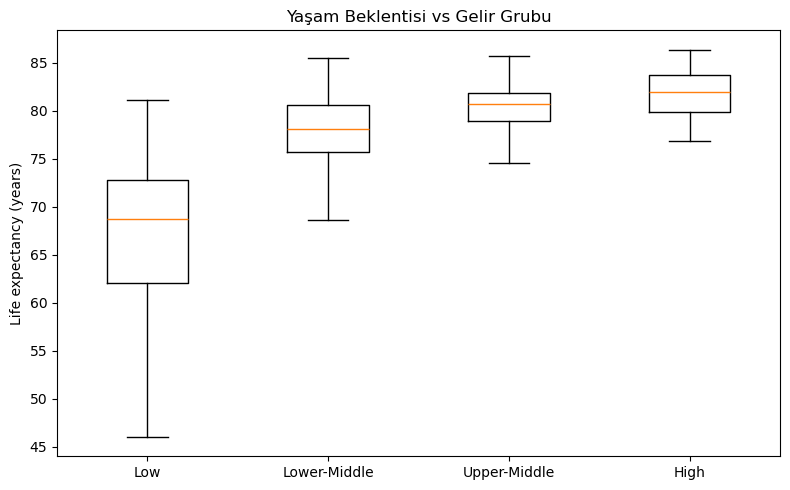

Kaydedildi: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\lifeexp_box.png


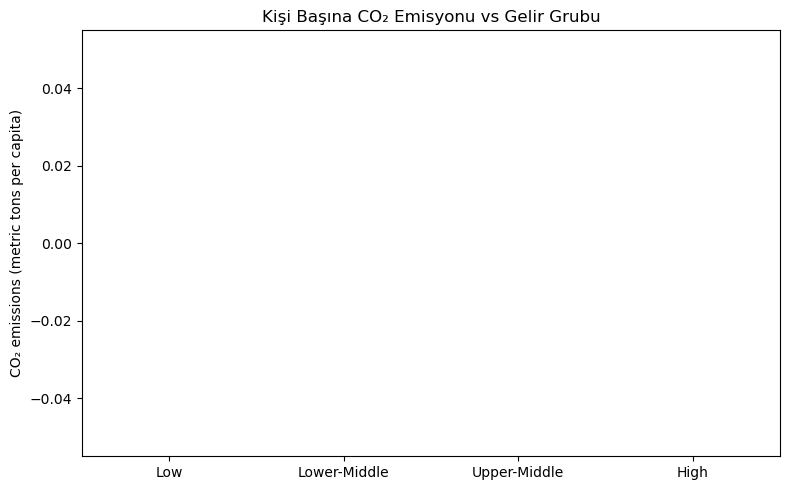

Kaydedildi: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\co2_box.png


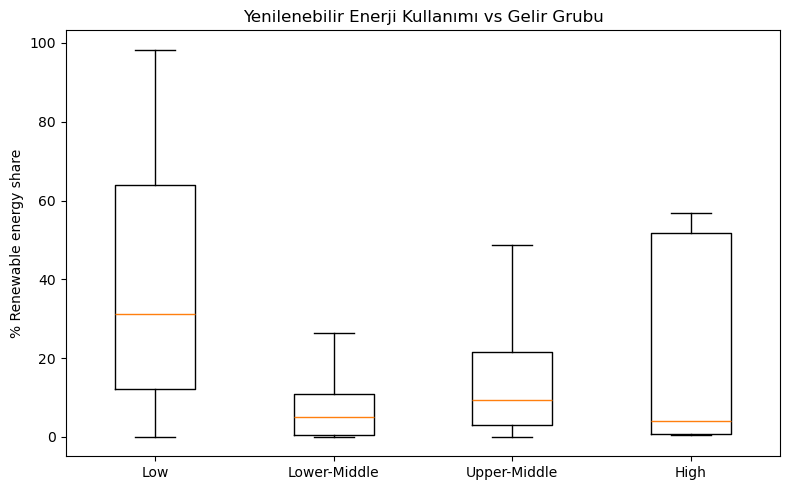

Kaydedildi: C:\Users\musta\udemy_ML\Machine Learning\ytu_datath\figures\renew_box.png


In [5]:

# 4) Görselleştirmeler
def boxplot_by_group(df, indicator_code, title, ylabel, fname):
    tmp = df[df['Indicator Code']==indicator_code]
    order = ["Low","Lower-Middle","Upper-Middle","High"]
    plt.figure(figsize=(8,5))
    data = [tmp[tmp['Group']==g]['Value'].dropna() for g in order]
    plt.boxplot(data, labels=order, showfliers=False)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    out = FIG_DIR / fname
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("Kaydedildi:", out)

boxplot_by_group(focus, "SP.DYN.LE00.IN", "Yaşam Beklentisi vs Gelir Grubu", "Life expectancy (years)", "lifeexp_box.png")
boxplot_by_group(focus, "EN.ATM.CO2E.PC", "Kişi Başına CO₂ Emisyonu vs Gelir Grubu", "CO₂ emissions (metric tons per capita)", "co2_box.png")
boxplot_by_group(focus, "EG.FEC.RNEW.ZS", "Yenilenebilir Enerji Kullanımı vs Gelir Grubu", "% Renewable energy share", "renew_box.png")


In [6]:

# 5) Korelasyon Görselleri
gdp_latest = focus[focus['Indicator Code']=="NY.GDP.PCAP.CD"].groupby('Country Code').apply(lambda d: d.sort_values('Year').iloc[-1]).reset_index(drop=True)
life_latest = focus[focus['Indicator Code']=="SP.DYN.LE00.IN"].groupby('Country Code').apply(lambda d: d.sort_values('Year').iloc[-1]).reset_index(drop=True)
co2_latest = focus[focus['Indicator Code']=="EN.ATM.CO2E.PC"].groupby('Country Code').apply(lambda d: d.sort_values('Year').iloc[-1]).reset_index(drop=True)

merged = gdp_latest[['Country Code','Country Name','Value','Group']].rename(columns={'Value':'GDP_percap'})
merged = merged.merge(life_latest[['Country Code','Value']], on='Country Code', how='left').rename(columns={'Value':'LifeExp'})
merged = merged.merge(co2_latest[['Country Code','Value']], on='Country Code', how='left').rename(columns={'Value':'CO2'})

plt.figure(figsize=(6,5))
for grp in ["Low","Lower-Middle","Upper-Middle","High"]:
    tmp = merged[merged['Group']==grp]
    plt.scatter(tmp['GDP_percap'], tmp['LifeExp'], label=grp, alpha=0.7)
plt.xscale("log")
plt.xlabel("GDP per capita (log scale)")
plt.ylabel("Life expectancy (years)")
plt.title("Kalkınma ve Sağlık Arasındaki İlişki")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_gdp_lifeexp.png", dpi=200)
plt.show()

plt.figure(figsize=(6,5))
for grp in ["Low","Lower-Middle","Upper-Middle","High"]:
    tmp = merged[merged['Group']==grp]
    plt.scatter(tmp['GDP_percap'], tmp['CO2'], label=grp, alpha=0.7)
plt.xscale("log")
plt.xlabel("GDP per capita (log scale)")
plt.ylabel("CO₂ emissions per capita")
plt.title("Kalkınma ve Çevre Arasındaki Gerilim")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "scatter_gdp_co2.png", dpi=200)
plt.show()


ValueError: Data has no positive values, and therefore cannot be log-scaled.

Error in callback <function _draw_all_if_interactive at 0x00000232DE757A60> (for post_execute), with arguments args (),kwargs {}:


ValueError: Data has no positive values, and therefore cannot be log-scaled.

ValueError: Data has no positive values, and therefore cannot be log-scaled.

<Figure size 600x500 with 1 Axes>

In [ ]:

# 6) Zaman Serisi Eğilimleri
trend = focus[focus['Indicator Code'].isin(["SP.DYN.LE00.IN","EN.ATM.CO2E.PC"])]
trend_group = trend.groupby(['Year','Indicator','Group'])['Value'].mean().reset_index()

fig, ax = plt.subplots(1,2, figsize=(12,5))
for grp in ["Low","Lower-Middle","Upper-Middle","High"]:
    sub_life = trend_group[(trend_group['Group']==grp)&(trend_group['Indicator']=="SP.DYN.LE00.IN")]
    ax[0].plot(sub_life['Year'], sub_life['Value'], label=grp)
ax[0].set_title("Yaşam Beklentisi – 2000–2023")
ax[0].set_xlabel("Yıl")
ax[0].set_ylabel("Yıl ortalaması (years)")

for grp in ["Low","Lower-Middle","Upper-Middle","High"]:
    sub_co2 = trend_group[(trend_group['Group']==grp)&(trend_group['Indicator']=="EN.ATM.CO2E.PC")]
    ax[1].plot(sub_co2['Year'], sub_co2['Value'], label=grp)
ax[1].set_title("CO₂ Emisyonu – 2000–2023")
ax[1].set_xlabel("Yıl")
ax[1].set_ylabel("Kişi başına CO₂ (tons)")
ax[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "timeseries_life_co2.png", dpi=200)
plt.show()



## 🧩 Sunum Hikayesi (4 Slaytlık Öneri)
**1️⃣ Giriş – Kalkınmanın Bedeli:** Kalkınma sağlık getiriyor, ama çevre bedeliyle.  
**2️⃣ Ekonomi & Sağlık:** GSYİH ile yaşam süresi arasında güçlü ilişki, düşük gelirden orta gelire geçişte en hızlı kazanım.  
**3️⃣ Ekonomi & Çevre:** GSYİH artışı CO₂ artışını tetikliyor, yenilenebilir enerji payı denge unsuru.  
**4️⃣ Zaman Serisi:** 2000–2023’te yaşam süresi artıyor ama çevre yükü devam ediyor.

> “Sağlık ve refah artıyor, ama gezegen nefes alamıyor.” 🌍💨
